In [124]:
import math
import os
import csv
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

In [521]:
data_root = 'data'
user_number = '1'  # matches recorder -u / --user-number
diameter_mm = 80  # matches recorder -s / --diameter-mm
task_performed = 'yaw'  # matches recorder -t / --task-performed
trial_number = '1'  # matches recorder -tn / --trial-number


def get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    return os.path.join(
        data_root,
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
        f'trial_{trial_number}',
    )


def get_segmented_file_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    save_dir = os.path.join(
        data_root,
        'segmented_data',
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
    )
    os.makedirs(save_dir, exist_ok=True)
    return os.path.join(save_dir, f'trial_{trial_number}.csv')


# Recorder input layout example:
# data/user_1/50mm/roll/trial_1/index.csv
data_dir = get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number)
file_dir = get_segmented_file_dir(data_root, user_number, diameter_mm, task_performed, trial_number)

zero_height = 0.2

# Per-trial threshold overrides can live here when a specific recording needs them.
zero_height_overrides = {
    # ('1', 50, 'pitch', '1'): 0.01,
}
zero_height = zero_height_overrides.get(
    (str(user_number), int(diameter_mm), task_performed, str(trial_number)),
    zero_height,
)

In [522]:
def load_data(data_dir):
    thumb_path = os.path.join(data_dir, 'thumb.csv')
    index_path = os.path.join(data_dir, 'index.csv')
    middle_path = os.path.join(data_dir, 'middle.csv')

    thumb = pd.read_csv(thumb_path)
    index = pd.read_csv(index_path)
    middle = pd.read_csv(middle_path)

    # The recorder writes one CSV per finger. Truncate to the shortest stream so
    # the combined force matrix has synchronized rows by sample index.
    n_samples = min(len(thumb), len(index), len(middle))
    force_data = np.column_stack([
        thumb[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        index[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        middle[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
    ])

    return force_data

In [523]:
def pca_analysis(data, n_components=9, force_threshold=0.1):
    print(f"Before clipping, data samples: {data.shape[0]}")
    if n_components == 9:
        s1_force = data[:, 0:3]
        s2_force = data[:, 3:6]
        s3_force = data[:, 6:9]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
    elif n_components == 18:
        s1_force = data[:, 0:3]
        s2_force = data[:, 6:9]
        s3_force = data[:, 12:15]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
        scaler = StandardScaler()
        data_filtered = scaler.fit_transform(data_filtered)

    print(f"After clipping, data samples: {data_filtered.shape[0]}")

    pca = PCA(n_components=n_components)
    pca.fit_transform(data_filtered)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [524]:
def plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed: bool=False):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    if transformed:
        axis_labels = ['Grav', 'Lateral', 'Normal'] * 3
    else:
        axis_labels = ['Fx', 'Fy', 'Fz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [3, 6]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([1.5, 4.5, 7.5], ["Thumb", "Index", "Middle"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{task_performed.capitalize()}, Trial {trial_number}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [525]:
def plot_pca_heatmap_horizontal_ft(pca_components, eigenvalues, explained_variance_ratio):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    axis_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [6, 12]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([3, 9, 15], ["Thumb", "Index", "Middle"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{task_performed.capitalize()}, Trial {trial_number}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force and Torque Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [526]:
def pca_analysis_and_plot(data, transformed_flag=True, visualize=True):
    pca_components, eigenvalues, explained_variance_ratio = pca_analysis(data, data.shape[1])
    if visualize:
        plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed_flag)

In [527]:
def main_analysis(data_dir):
    force_data = load_data(data_dir)
    print('Recorded Force Data Analysis:')
    pca_components, eigenvalues, explained_variance_ratio = pca_analysis(force_data, force_data.shape[1])
    plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed=False)

In [528]:
def quick_visualization(data, visualize_data = 'transformed'):

    max_val = np.max(data)
    min_val = np.min(data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(data[:, 0])
    ax1.plot(data[:, 1])
    ax1.plot(data[:, 2])
    ax1.set_title(f'{visualize_data.capitalize()} Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(data[:, 3])
    ax2.plot(data[:, 4])
    ax2.plot(data[:, 5])
    ax2.set_title(f'{visualize_data.capitalize()} Force Data - Index')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(data[:, 6])
    ax3.plot(data[:, 7])
    ax3.plot(data[:, 8])
    ax3.set_title(f'{visualize_data.capitalize()} Force Data - Middle')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [529]:
def split_contiguous_regions(idx):
    """
    split_contiguous_regions takes a list of sorted integers and splits them into contiguous regions.
    For example, if idx = [1, 2, 3, 5, 6, 10], it will return [(1, 3), (5, 6), (10, 10)].
    """
    if len(idx) == 0:
        print("No indices provided. Returning empty list.")
        return []
    
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    regions = [(g[0], g[-1]) for g in groups]
    return regions

def group_peaks_between_zero_regions(peaks, zero_idx, total_len):
    peaks = np.asarray(peaks)
    zero_regions = split_contiguous_regions(zero_idx)
    min_zero_duration = 5

    zero_regions = [
        r for r in zero_regions
        if (r[1] - r[0] + 1) >= min_zero_duration
    ]

    peak_groups = []

    for i in range(len(zero_regions)):
        left_end = zero_regions[i][1]
        # last zero region: extend to end of data instead of skipping
        right_start = zero_regions[i + 1][0] if i < len(zero_regions) - 1 else total_len-1

        mask = (peaks > left_end) & (peaks < right_start)
        if np.any(mask):
            peak_groups.append({
                "start": left_end,
                "end": right_start,
                "peaks": peaks[mask]
            })

    return peak_groups

def mask_calculation(force_data, data_height=.3, zero_height=0.0, visualize=True):

    peaks_thumb_z = find_peaks(abs(force_data[:, 2]), height=data_height, distance=20, prominence=0.05)[0]
    peaks_index_z = find_peaks(abs(force_data[:, 5]), height=data_height, distance=20, prominence=0.05)[0]
    peaks_middle_z = find_peaks(abs(force_data[:, 8]), height=data_height, distance=20, prominence=0.05)[0]

    thumb_z_smooth = uniform_filter1d(np.abs(force_data[:, 2]), size=20)
    index_z_smooth = uniform_filter1d(np.abs(force_data[:, 5]), size=20)
    middle_z_smooth = uniform_filter1d(np.abs(force_data[:, 8]), size=20)

    zero_idx_thumb_z = np.where(thumb_z_smooth < zero_height)[0]
    zero_idx_index_z = np.where(index_z_smooth < zero_height)[0]
    zero_idx_middle_z = np.where(middle_z_smooth < zero_height)[0]

    thumb_peak_regions = group_peaks_between_zero_regions(peaks_thumb_z, zero_idx_thumb_z, force_data.shape[0])
    index_peak_regions = group_peaks_between_zero_regions(peaks_index_z, zero_idx_index_z, force_data.shape[0])
    middle_peak_regions = group_peaks_between_zero_regions(peaks_middle_z, zero_idx_middle_z, force_data.shape[0])
    
    n_thumb = len(thumb_peak_regions)
    n_index = len(index_peak_regions)
    n_middle = len(middle_peak_regions)

    cycle_len = min(n_thumb, n_index, n_middle)

    print(f"Thumb peak regions: {n_thumb}, Index peak regions: {n_index}, Middle peak regions: {n_middle}")
    if cycle_len == 0:
        print("No valid peak regions found for at least one finger. Returning empty array.")
        return np.array([])

    thumb_peak_regions = thumb_peak_regions[:cycle_len]
    index_peak_regions = index_peak_regions[:cycle_len]
    middle_peak_regions = middle_peak_regions[:cycle_len]

    max_val = np.max(force_data)
    min_val = np.min(force_data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    data_mask = []
    if visualize:
        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(311)
        ax1.plot(force_data[:, 0])
        ax1.plot(force_data[:, 1])
        ax1.plot(force_data[:, 2])
        ax1.plot(peaks_thumb_z, force_data[peaks_thumb_z, 2], 'rx')
        ax1.plot(zero_idx_thumb_z, force_data[zero_idx_thumb_z, 2], 'ko', markersize=3)
        ax1.set_title('Recorded Force Data - Thumb')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Force (N)')
        ax1.legend(['Fx', 'Fy', 'Fz'])
        ax1.set_ylim(low_bound, up_bound)

        ax2 = fig.add_subplot(312)
        ax2.plot(force_data[:, 3])
        ax2.plot(force_data[:, 4])
        ax2.plot(force_data[:, 5])
        ax2.plot(peaks_index_z, force_data[peaks_index_z, 5], 'rx')
        ax2.plot(zero_idx_index_z, force_data[zero_idx_index_z, 5], 'ko', markersize=3)
        ax2.set_title('Recorded Force Data - Index')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Force (N)')
        ax2.legend(['Fx', 'Fy', 'Fz'])
        ax2.set_ylim(low_bound, up_bound)

        ax3 = fig.add_subplot(313)
        ax3.plot(force_data[:, 6])
        ax3.plot(force_data[:, 7])
        ax3.plot(force_data[:, 8])
        ax3.plot(peaks_middle_z, force_data[peaks_middle_z, 8], 'rx')
        ax3.plot(zero_idx_middle_z, force_data[zero_idx_middle_z, 8], 'ko', markersize=3)
        ax3.set_title('Recorded Force Data - Middle')
        ax3.set_xlabel('Time')
        ax3.set_ylabel('Force (N)')
        ax3.legend(['Fx', 'Fy', 'Fz'])
        ax3.set_ylim(low_bound, up_bound)

    pad = 5  # samples of margin around the peak cluster, tune to taste

    for i in range(cycle_len):
        thumb_region = thumb_peak_regions[i]
        index_region = index_peak_regions[i]
        middle_region = middle_peak_regions[i]

        # still use the union for building the shared data_mask (for saving/PCA)
        start_idx = min(thumb_region["start"], index_region["start"], middle_region["start"])
        end_idx = max(thumb_region["end"], index_region["end"], middle_region["end"])

        if visualize:
            ax1.axvspan(max(thumb_region["start"] - pad, 0),
                        thumb_region["end"] + pad, color='red', alpha=0.3)
            ax2.axvspan(max(index_region["start"] - pad, 0),
                        index_region["end"] + pad, color='red', alpha=0.3)
            ax3.axvspan(max(middle_region["start"] - pad, 0),
                        middle_region["end"] + pad, color='red', alpha=0.3)

        data_mask.extend(list(range(start_idx, end_idx + 1)))
    data_mask = np.array(data_mask, dtype=int)
    if data_mask.size == 0:
        print(
            'No overlapping masked region found. Try lowering data_height or adjusting zero_height. '
            'Returning an empty array.'
        )
        if visualize:
            plt.tight_layout()
            plt.show()
        return np.empty((0, force_data.shape[1]))

    masked_data = force_data[data_mask, :]
    if visualize:
        plt.tight_layout()
        plt.show()
    return masked_data




In [530]:
force_data = load_data(data_dir)

In [531]:
print("force_data shape:", force_data.shape)

print("Thumb Fz max:", np.max(np.abs(force_data[:, 2])))
print("Index Fz max:", np.max(np.abs(force_data[:, 5])))
print("Middle Fz max:", np.max(np.abs(force_data[:, 8])))

force_data shape: (13106, 9)
Thumb Fz max: 9.704880553
Index Fz max: 4.547598307
Middle Fz max: 4.944886061


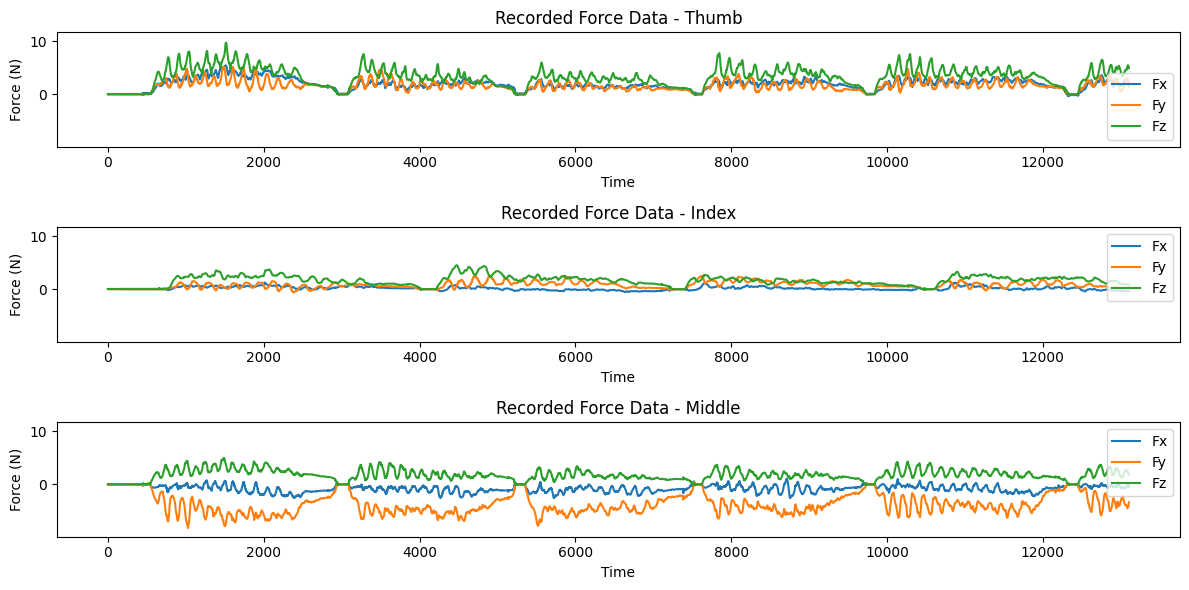

In [532]:
quick_visualization(force_data, visualize_data='recorded')

Thumb peak regions: 6, Index peak regions: 4, Middle peak regions: 6


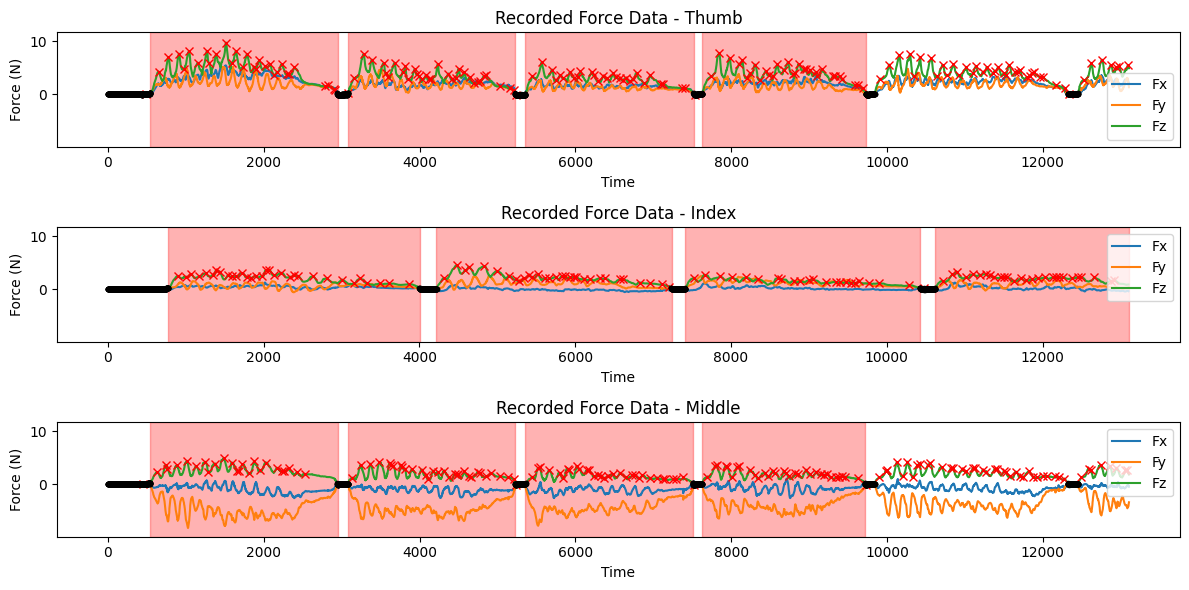

In [533]:
masked_data = mask_calculation(force_data, data_height=0.1, zero_height=zero_height)

In [534]:
os.makedirs(os.path.dirname(file_dir), exist_ok=True)

if masked_data.size == 0:
    print(f'Not saving because masked_data is empty: {masked_data.shape}')
else:
    with open(file_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(masked_data)
    print(f'Saved masked data to {file_dir}')

Saved masked data to data/segmented_data/user_1/80mm/yaw/trial_1.csv


Before clipping, data samples: 18157
After clipping, data samples: 18157
PC  | Eigenvalue | Variance Ratio
----------------------------------------
PC1   | 6.0014     | 66.01%
PC2   | 1.0349     | 11.38%
PC3   | 0.6945     | 7.64%
PC4   | 0.6169     | 6.79%
PC5   | 0.3069     | 3.38%
PC6   | 0.1945     | 2.14%
PC7   | 0.1021     | 1.12%
PC8   | 0.0741     | 0.82%
PC9   | 0.0656     | 0.72%
----------------------------------------
Sum of eigenvalues: 9.0910



/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decompo

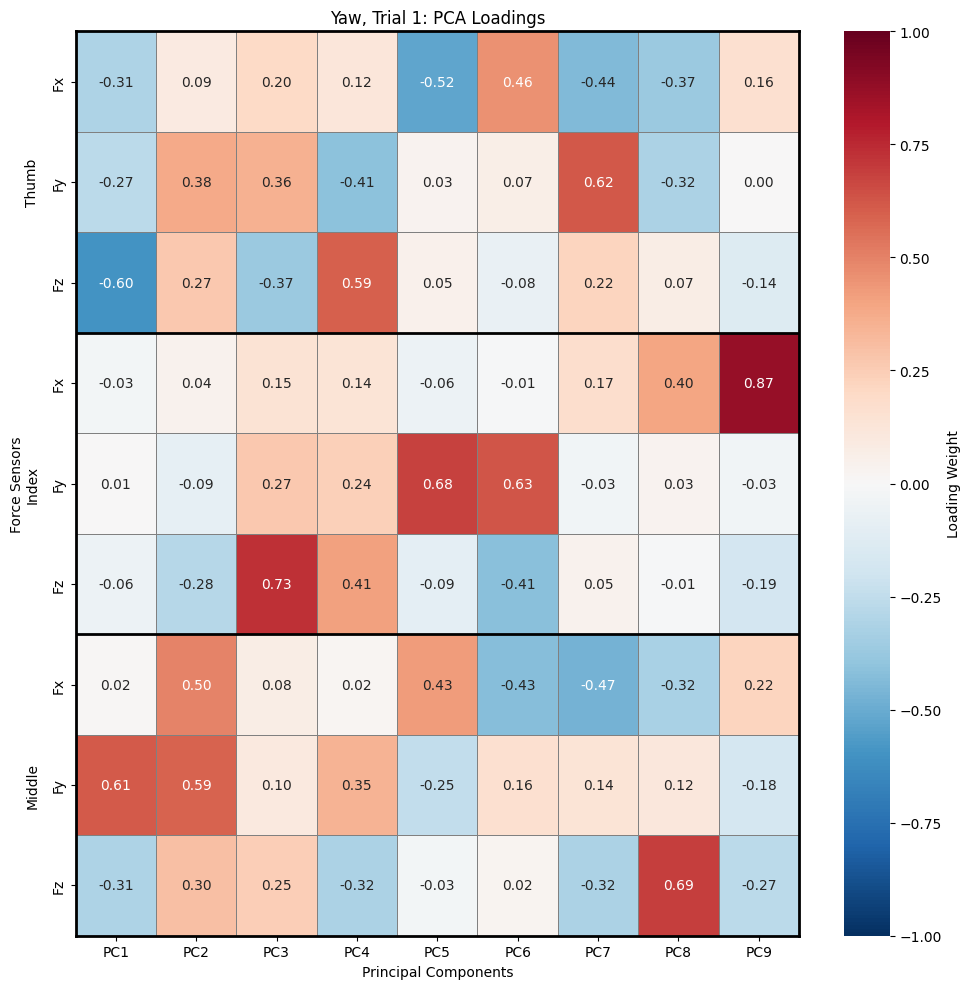

In [535]:
pca_analysis_and_plot(masked_data, transformed_flag=False, visualize=True)